In [1]:
# AUTOMATED DATA CLEANING & REPORTING
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Mounted at /content/drive
Libraries imported successfully!


In [2]:
DATA_PATH = "/content/drive/MyDrive/student_dataset/messy_student_dataset.csv"

df_raw = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print(f"Shape: {df_raw.shape}")

display(df_raw.head())

Dataset loaded successfully!
Shape: (152, 9)


,StudentID,Name,Age,Gender,Attendance_Percentage,Internal_Marks_50,External_Marks_100,Study_Hours_Per_Week,Monthly_Family_Income
0,CSS234-0089,Vikram Reddy,20.0,FEMALE,74.6,31.8,68.8,NaN,NaN
1,CSS234-0126,myra singh,NaN,MALE,96.8,14.5,68.3,0.0,39466.0
2,CSS234-0046,Navya Bose,19.0,female,82.6,NaN,48.2,11.8,52577.0
3,CSS234-0012,Myra Naidu,20.0,female,80.4,32.5,53.3,7.5,24168.0
4,CSS234-0053,Pooja Krishnan,18.0,m,90.9,30.8,76.7,11.9,-1.0


In [3]:
def profile_dataset(df):
    profile = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str).values,
        "Missing Values": df.isnull().sum().values,
        "Missing %": (df.isnull().mean() * 100).round(2).values,
        "Unique Values": df.nunique(dropna=True).values
    })

    return profile


profile = profile_dataset(df_raw)

print("========== DATASET PROFILE ==========")
print(f"Rows    : {df_raw.shape[0]:,}")
print(f"Columns : {df_raw.shape[1]}")
print(f"Duplicate Rows : {df_raw.duplicated().sum():,}")

display(profile)

========== DATASET PROFILE ==========
Rows    : 152
Columns : 9
Duplicate Rows : 6


,Column,Data Type,Missing Values,Missing %,Unique Values
0,StudentID,object,0,0.00,140
1,Name,object,0,0.00,135
2,Age,float64,8,5.26,8
3,Gender,object,4,2.63,10
4,Attendance_Percentage,float64,14,9.21,112
5,Internal_Marks_50,float64,11,7.24,104
6,External_Marks_100,float64,7,4.61,119
7,Study_Hours_Per_Week,float64,12,7.89,96
8,Monthly_Family_Income,float64,12,7.89,124


In [4]:
total_cells = df_raw.shape[0] * df_raw.shape[1]
missing_cells = df_raw.isnull().sum().sum()
duplicate_rows = df_raw.duplicated().sum()

quality_summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Total Cells",
        "Missing Cells",
        "Duplicate Rows"
    ],
    "Value": [
        df_raw.shape[0],
        df_raw.shape[1],
        total_cells,
        missing_cells,
        duplicate_rows
    ]
})

display(quality_summary)

print("\n========== COLUMN DATA TYPES ==========")
display(df_raw.dtypes.to_frame("Data Type"))

,Metric,Value
0,Total Rows,152
1,Total Columns,9
2,Total Cells,1368
3,Missing Cells,68
4,Duplicate Rows,6



========== COLUMN DATA TYPES ==========


,Data Type
StudentID,object
Name,object
Age,float64
Gender,object
Attendance_Percentage,float64
Internal_Marks_50,float64
External_Marks_100,float64
Study_Hours_Per_Week,float64
Monthly_Family_Income,float64


In [5]:

print("========== MISSING VALUES ==========")
missing = df_raw.isnull().sum()
display(missing[missing > 0].sort_values(ascending=False).to_frame("Missing Count"))

print("\n========== DUPLICATE RECORDS ==========")
print(f"Exact duplicate rows : {df_raw.duplicated().sum()}")

print("\n========== DUPLICATE STUDENT IDs ==========")
duplicate_ids = df_raw[df_raw["StudentID"].duplicated(keep=False)].sort_values("StudentID")

print(f"Rows with duplicated Student IDs : {len(duplicate_ids)}")
print(f"Unique duplicated Student IDs     : {duplicate_ids['StudentID'].nunique()}")

display(duplicate_ids)

========== MISSING VALUES ==========


,Missing Count
Attendance_Percentage,14
Study_Hours_Per_Week,12
Monthly_Family_Income,12
Internal_Marks_50,11
Age,8
External_Marks_100,7
Gender,4



========== DUPLICATE RECORDS ==========
Exact duplicate rows : 6

========== DUPLICATE STUDENT IDs ==========
Rows with duplicated Student IDs : 24
Unique duplicated Student IDs     : 12


,StudentID,Name,Age,Gender,Attendance_Percentage,Internal_Marks_50,External_Marks_100,Study_Hours_Per_Week,Monthly_Family_Income
18,CSS234-0006,Pari Shetty,20.0,M,62.4,40.3,58.6,0.0,45692.0
39,CSS234-0006,Pari Shetty,20.0,M,62.4,40.3,58.6,0.0,45692.0
106,CSS234-0009,SAI PATEL,20.0,m,74.4,NaN,79.3,6.4,49462.0
62,CSS234-0009,sai patel,20.0,m,69.9,NaN,79.3,6.4,49462.0
29,CSS234-0030,DIVYA JOSHI,21.0,FEMALE,52.8,27.8,340.0,NaN,71296.0
51,CSS234-0030,Divya Joshi,21.0,FEMALE,56.0,27.8,340.0,NaN,71296.0
147,CSS234-0043,Priya Mehta,21.0,m,90.8,25.6,69.2,5.3,58402.0
142,CSS234-0043,Priya Mehta,21.0,m,90.8,25.6,69.2,5.3,58402.0
108,CSS234-0047,LAKSHMI RAO,20.0,M,72.4,25.2,71.7,13.4,20304.0
31,CSS234-0047,Lakshmi Rao,20.0,M,76.4,25.2,71.7,13.4,20304.0


In [6]:

print("========== UNIQUE GENDER VALUES ==========")

gender_values = (
    df_raw["Gender"]
    .dropna()
    .astype(str)
    .str.strip()
    .value_counts()
)

display(gender_values.to_frame("Count"))

print("\n========== NAME FORMATTING SAMPLE ==========")
display(df_raw[["StudentID", "Name"]].head(20))

========== UNIQUE GENDER VALUES ==========


,Count
Gender,
M,19
m,18
MALE,17
female,16
male,16
FEMALE,15
Male,14
f,13
Female,11



========== NAME FORMATTING SAMPLE ==========


,StudentID,Name
0,CSS234-0089,Vikram Reddy
1,CSS234-0126,myra singh
2,CSS234-0046,Navya Bose
3,CSS234-0012,Myra Naidu
4,CSS234-0053,Pooja Krishnan
5,CSS234-0140,Kabir Iyer
6,CSS234-0115,Pari Reddy
7,CSS234-0067,Ananya Das
8,CSS234-0038,Sneha Singh
9,CSS234-0065,ARYAN VERMA


In [7]:

range_checks = {
    "Age": (15, 30),
    "Attendance_Percentage": (0, 100),
    "Internal_Marks_50": (0, 50),
    "External_Marks_100": (0, 100),
    "Study_Hours_Per_Week": (0, 168),
    "Monthly_Family_Income": (0, float("inf"))
}

for column, (minimum, maximum) in range_checks.items():

    invalid = df_raw[
        (df_raw[column].notna()) &
        ((df_raw[column] < minimum) | (df_raw[column] > maximum))
    ]

    print(f"\n{column}")
    print(f"  Valid range : {minimum} → {maximum}")
    print(f"  Invalid records : {len(invalid)}")

    if len(invalid) > 0:
        display(invalid[["StudentID", column]])


Age
  Valid range : 15 → 30
  Invalid records : 4


,StudentID,Age
28,CSS234-0106,84.0
71,CSS234-0015,84.0
87,CSS234-0058,5.0
104,CSS234-0036,150.0



Attendance_Percentage
  Valid range : 0 → 100
  Invalid records : 5


,StudentID,Attendance_Percentage
47,CSS234-0052,999.0
116,CSS234-0084,999.0
117,CSS234-0084,999.0
139,CSS234-0128,999.0
140,CSS234-0069,999.0



Internal_Marks_50
  Valid range : 0 → 50
  Invalid records : 4


,StudentID,Internal_Marks_50
34,CSS234-0023,-1.0
81,CSS234-0019,200.0
132,CSS234-0045,-10.0
145,CSS234-0073,87.0



External_Marks_100
  Valid range : 0 → 100
  Invalid records : 4


,StudentID,External_Marks_100
29,CSS234-0030,340.0
51,CSS234-0030,340.0
114,CSS234-0002,105.0
137,CSS234-0001,105.0



Study_Hours_Per_Week
  Valid range : 0 → 168
  Invalid records : 0

Monthly_Family_Income
  Valid range : 0 → inf
  Invalid records : 5


,StudentID,Monthly_Family_Income
4,CSS234-0053,-1.0
6,CSS234-0115,-1.0
47,CSS234-0052,-1.0
50,CSS234-0075,-1.0
119,CSS234-0100,-1.0


In [8]:
# Cell 8: Statistical Overview
print("========== NUMERICAL SUMMARY ==========")

display(
    df_raw.describe()
    .T
    .round(2)
)

========== NUMERICAL SUMMARY ==========


,count,mean,std,min,25%,50%,75%,max
Age,144.0,21.72,13.27,5.0,19.00,20.0,21.00,150.0
Attendance_Percentage,138.0,109.83,173.47,42.4,68.22,76.8,86.75,999.0
Internal_Marks_50,141.0,35.35,17.30,-10.0,28.00,34.4,39.60,200.0
External_Marks_100,145.0,68.28,35.49,30.2,53.30,65.2,75.30,340.0
Study_Hours_Per_Week,140.0,13.70,17.41,0.0,7.80,11.9,14.42,168.0
Monthly_Family_Income,140.0,45629.95,19278.60,-1.0,34849.25,47395.5,57649.50,101184.0


In [9]:
#Preserve Raw Dataset
df = df_raw.copy()

print(f"Raw dataset preserved: {df.shape}")

Raw dataset preserved: (152, 9)


In [10]:

df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
)

print("Standardized column names:")
print(df.columns.tolist())

Standardized column names:
['StudentID', 'Name', 'Age', 'Gender', 'Attendance_Percentage', 'Internal_Marks_50', 'External_Marks_100', 'Study_Hours_Per_Week', 'Monthly_Family_Income']


In [11]:

# Clean student names
df["Name"] = (
    df["Name"]
    .astype(str)
    .str.strip()
    .str.title()
)

# Standardize gender
df["Gender"] = (
    df["Gender"]
    .astype("string")
    .str.strip()
    .str.lower()
)

gender_mapping = {
    "m": "Male",
    "male": "Male",
    "ma": "Male",
    "f": "Female",
    "female": "Female",
    "fe": "Female"
}

df["Gender"] = df["Gender"].replace(gender_mapping)

print("Gender values after standardization:")
print(df["Gender"].value_counts(dropna=False))

Gender values after standardization:
Gender
Male      84
Female    64
<NA>       4
Name: count, dtype: Int64


In [12]:
validation_rules = {
    "Age": (17, 30),
    "Attendance_Percentage": (0, 100),
    "Internal_Marks_50": (0, 50),
    "External_Marks_100": (0, 100),
    "Study_Hours_Per_Week": (0, 168),
    "Monthly_Family_Income": (0, float("inf"))
}

invalid_counts = {}

for column, (minimum, maximum) in validation_rules.items():

    invalid_mask = (
        df[column].notna() &
        ((df[column] < minimum) | (df[column] > maximum))
    )

    invalid_counts[column] = invalid_mask.sum()

    # Convert invalid values to missing
    df.loc[invalid_mask, column] = np.nan

print("========== INVALID VALUES DETECTED ==========")

for column, count in invalid_counts.items():
    print(f"{column}: {count}")

========== INVALID VALUES DETECTED ==========
Age: 4
Attendance_Percentage: 5
Internal_Marks_50: 4
External_Marks_100: 4
Study_Hours_Per_Week: 0
Monthly_Family_Income: 5


In [13]:

# Numerical columns → median
numerical_columns = [
    "Age",
    "Attendance_Percentage",
    "Internal_Marks_50",
    "External_Marks_100",
    "Study_Hours_Per_Week",
    "Monthly_Family_Income"
]

for column in numerical_columns:
    median_value = df[column].median()
    df[column] = df[column].fillna(median_value)

# Gender → mode
gender_mode = df["Gender"].mode()[0]
df["Gender"] = df["Gender"].fillna(gender_mode)

print("Missing values handled successfully! ")

display(
    df.isnull()
      .sum()
      .to_frame("Remaining Missing Values")
)

Missing values handled successfully! 


,Remaining Missing Values
StudentID,0
Name,0
Age,0
Gender,0
Attendance_Percentage,0
Internal_Marks_50,0
External_Marks_100,0
Study_Hours_Per_Week,0
Monthly_Family_Income,0


In [14]:

exact_duplicates = df.duplicated().sum()

duplicate_id_rows = df[df["StudentID"].duplicated(keep=False)].sort_values("StudentID")

print("========== DUPLICATE AUDIT ==========")
print(f"Exact duplicate rows       : {exact_duplicates}")
print(f"Rows with duplicate IDs    : {len(duplicate_id_rows)}")
print(f"Unique duplicated IDs      : {duplicate_id_rows['StudentID'].nunique()}")

print("\n========== DUPLICATED STUDENT RECORDS ==========")
display(duplicate_id_rows)

========== DUPLICATE AUDIT ==========
Exact duplicate rows       : 6
Rows with duplicate IDs    : 24
Unique duplicated IDs      : 12

========== DUPLICATED STUDENT RECORDS ==========


,StudentID,Name,Age,Gender,Attendance_Percentage,Internal_Marks_50,External_Marks_100,Study_Hours_Per_Week,Monthly_Family_Income
18,CSS234-0006,Pari Shetty,20.0,Male,62.4,40.3,58.6,0.0,45692.0
39,CSS234-0006,Pari Shetty,20.0,Male,62.4,40.3,58.6,0.0,45692.0
106,CSS234-0009,Sai Patel,20.0,Male,74.4,34.4,79.3,6.4,49462.0
62,CSS234-0009,Sai Patel,20.0,Male,69.9,34.4,79.3,6.4,49462.0
29,CSS234-0030,Divya Joshi,21.0,Female,52.8,27.8,65.2,11.9,71296.0
51,CSS234-0030,Divya Joshi,21.0,Female,56.0,27.8,65.2,11.9,71296.0
147,CSS234-0043,Priya Mehta,21.0,Male,90.8,25.6,69.2,5.3,58402.0
142,CSS234-0043,Priya Mehta,21.0,Male,90.8,25.6,69.2,5.3,58402.0
108,CSS234-0047,Lakshmi Rao,20.0,Male,72.4,25.2,71.7,13.4,20304.0
31,CSS234-0047,Lakshmi Rao,20.0,Male,76.4,25.2,71.7,13.4,20304.0


In [15]:

before_duplicates = len(df)

df = df.drop_duplicates().reset_index(drop=True)

removed_duplicates = before_duplicates - len(df)

print(f"Exact duplicate rows removed: {removed_duplicates}")
print(f"Rows remaining: {len(df)}")

Exact duplicate rows removed: 6
Rows remaining: 146


In [16]:
#StudentID Integrity Check
remaining_duplicate_ids = df["StudentID"].duplicated().sum()

print("========== FINAL ID VALIDATION ==========")
print(f"Total records       : {len(df)}")
print(f"Unique Student IDs  : {df['StudentID'].nunique()}")
print(f"Duplicate IDs       : {remaining_duplicate_ids}")

if remaining_duplicate_ids == 0:
    print("StudentID integrity check PASSED")
else:
    print("Duplicate StudentIDs still require review")

========== FINAL ID VALIDATION ==========
Total records       : 146
Unique Student IDs  : 140
Duplicate IDs       : 6
Duplicate StudentIDs still require review


In [17]:
#Investigate Duplicate Student IDs
duplicate_id_mask = df["StudentID"].duplicated(keep=False)

duplicate_id_records = (
    df[duplicate_id_mask]
    .sort_values("StudentID")
    .reset_index(drop=True)
)

print("========== REMAINING DUPLICATE STUDENT IDs ==========")
print(f"Records requiring review: {len(duplicate_id_records)}")
print(f"Unique duplicated IDs: {duplicate_id_records['StudentID'].nunique()}")

display(duplicate_id_records)

========== REMAINING DUPLICATE STUDENT IDs ==========
Records requiring review: 12
Unique duplicated IDs: 6


,StudentID,Name,Age,Gender,Attendance_Percentage,Internal_Marks_50,External_Marks_100,Study_Hours_Per_Week,Monthly_Family_Income
0,CSS234-0009,Sai Patel,20.0,Male,69.9,34.4,79.3,6.4,49462.0
1,CSS234-0009,Sai Patel,20.0,Male,74.4,34.4,79.3,6.4,49462.0
2,CSS234-0030,Divya Joshi,21.0,Female,52.8,27.8,65.2,11.9,71296.0
3,CSS234-0030,Divya Joshi,21.0,Female,56.0,27.8,65.2,11.9,71296.0
4,CSS234-0047,Lakshmi Rao,20.0,Male,76.4,25.2,71.7,13.4,20304.0
5,CSS234-0047,Lakshmi Rao,20.0,Male,72.4,25.2,71.7,13.4,20304.0
6,CSS234-0065,Aryan Verma,19.0,Male,89.8,21.5,59.4,0.0,44907.0
7,CSS234-0065,Aryan Verma,19.0,Male,91.3,21.5,59.4,0.0,44907.0
8,CSS234-0067,Ananya Das,21.0,Male,82.2,26.7,65.2,7.8,68753.0
9,CSS234-0067,Ananya Das,21.0,Male,83.5,26.7,65.2,7.8,68753.0


In [18]:
# Identify duplicated Student IDs
duplicate_ids = df.loc[
    df["StudentID"].duplicated(keep=False),
    "StudentID"
].unique()

print(f"Duplicate Student IDs found: {len(duplicate_ids)}")

# Keep a record of the resolution
duplicate_resolution = []

for student_id in duplicate_ids:

    records = df[df["StudentID"] == student_id].copy()

    # Calculate mean attendance for duplicate records
    mean_attendance = records["Attendance_Percentage"].mean()

    duplicate_resolution.append({
        "StudentID": student_id,
        "Records_Before": len(records),
        "Attendance_Values": records["Attendance_Percentage"].tolist(),
        "Resolved_Attendance": round(mean_attendance, 2)
    })

    # Update attendance for all matching records
    df.loc[
        df["StudentID"] == student_id,
        "Attendance_Percentage"
    ] = mean_attendance

# Keep only one record per StudentID
df = df.drop_duplicates(subset="StudentID", keep="first").reset_index(drop=True)

duplicate_resolution_df = pd.DataFrame(duplicate_resolution)

print("\n========== DUPLICATE ID RESOLUTION ==========")
display(duplicate_resolution_df)

print(f"\nRecords after ID resolution: {len(df)}")
print(f"Unique Student IDs: {df['StudentID'].nunique()}")

Duplicate Student IDs found: 6

========== DUPLICATE ID RESOLUTION ==========


,StudentID,Records_Before,Attendance_Values,Resolved_Attendance
0,CSS234-0067,2,"[82.2, 83.5]",82.85
1,CSS234-0065,2,"[89.8, 91.3]",90.55
2,CSS234-0127,2,"[73.4, 73.7]",73.55
3,CSS234-0030,2,"[52.8, 56.0]",54.40
4,CSS234-0047,2,"[76.4, 72.4]",74.40
5,CSS234-0009,2,"[69.9, 74.4]",72.15



Records after ID resolution: 140
Unique Student IDs: 140


In [19]:
print("========== FINAL DATA QUALITY CHECK ==========")

print(f"Rows                  : {len(df)}")
print(f"Columns               : {len(df.columns)}")
print(f"Missing values        : {df.isnull().sum().sum()}")
print(f"Exact duplicates      : {df.duplicated().sum()}")
print(f"Duplicate Student IDs : {df['StudentID'].duplicated().sum()}")

print("\n========== RANGE VALIDATION ==========")

for column, (minimum, maximum) in validation_rules.items():

    invalid_count = (
        (df[column] < minimum) |
        (df[column] > maximum)
    ).sum()

    print(f"{column}: {invalid_count} invalid values")

print("\n========== FINAL RESULT ==========")

if (
    df.isnull().sum().sum() == 0
    and df.duplicated().sum() == 0
    and df["StudentID"].duplicated().sum() == 0
):
    print("DATA QUALITY CHECK PASSED")
    print("Dataset is clean and analysis-ready!")
else:
    print("Further cleaning required.")

========== FINAL DATA QUALITY CHECK ==========
Rows                  : 140
Columns               : 9
Missing values        : 0
Exact duplicates      : 0
Duplicate Student IDs : 0

========== RANGE VALIDATION ==========
Age: 0 invalid values
Attendance_Percentage: 0 invalid values
Internal_Marks_50: 0 invalid values
External_Marks_100: 0 invalid values
Study_Hours_Per_Week: 0 invalid values
Monthly_Family_Income: 0 invalid values

========== FINAL RESULT ==========
DATA QUALITY CHECK PASSED
Dataset is clean and analysis-ready!


In [20]:
#Data Cleaning Impact Summary
cleaning_summary = pd.DataFrame({
    "Quality Metric": [
        "Total Records",
        "Missing Values",
        "Exact Duplicate Rows",
        "Duplicate Student IDs",
        "Invalid Numerical Values"
    ],
    "Before Cleaning": [
        len(df_raw),
        df_raw.isnull().sum().sum(),
        df_raw.duplicated().sum(),
        df_raw["StudentID"].duplicated().sum(),
        sum(invalid_counts.values())
    ],
    "After Cleaning": [
        len(df),
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        df["StudentID"].duplicated().sum(),
        sum(
            (
                (df[column] < minimum) |
                (df[column] > maximum)
            ).sum()
            for column, (minimum, maximum) in validation_rules.items()
        )
    ]
})

display(cleaning_summary)

,Quality Metric,Before Cleaning,After Cleaning
0,Total Records,152,140
1,Missing Values,68,0
2,Exact Duplicate Rows,6,0
3,Duplicate Student IDs,12,0
4,Invalid Numerical Values,22,0


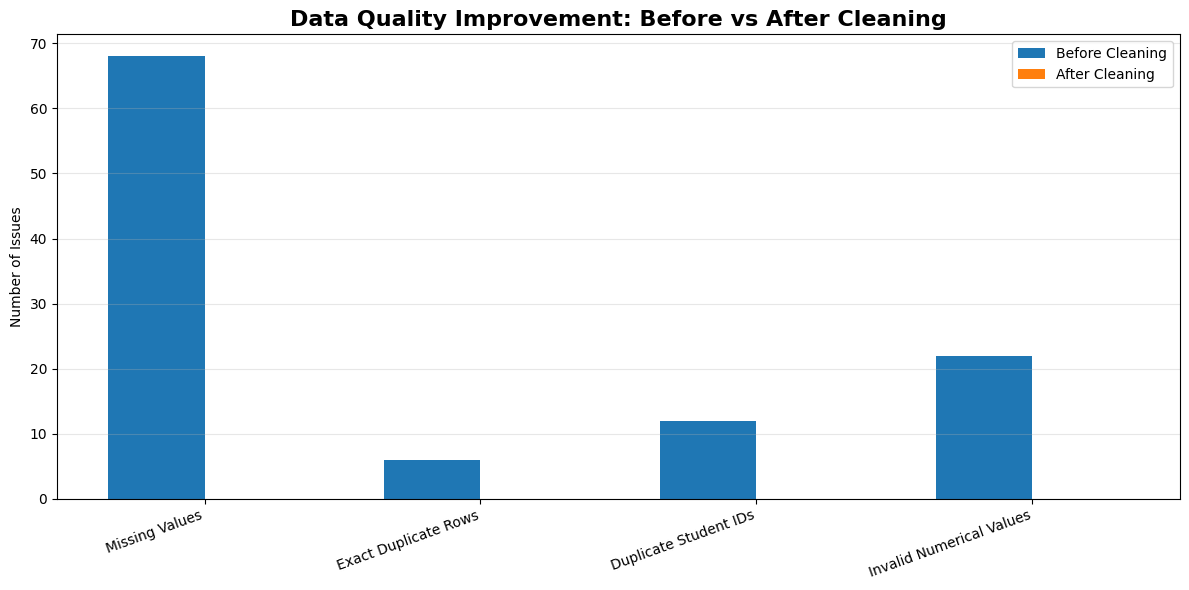

In [21]:
# ============================================
# Cell 21: Data Quality Before vs After
# ============================================

visual_metrics = cleaning_summary[
    cleaning_summary["Quality Metric"] != "Total Records"
].copy()

x = np.arange(len(visual_metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    x - width/2,
    visual_metrics["Before Cleaning"],
    width,
    label="Before Cleaning"
)

ax.bar(
    x + width/2,
    visual_metrics["After Cleaning"],
    width,
    label="After Cleaning"
)

ax.set_title(
    "Data Quality Improvement: Before vs After Cleaning",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel("Number of Issues")
ax.set_xticks(x)
ax.set_xticklabels(
    visual_metrics["Quality Metric"],
    rotation=20,
    ha="right"
)

ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
df["Total_Marks"] = (
    df["Internal_Marks_50"] +
    df["External_Marks_100"]
)

df["Maximum_Marks"] = 150

df["Performance_Percentage"] = (
    df["Total_Marks"] /
    df["Maximum_Marks"]
) * 100

# Performance categories
def classify_performance(score):
    if score >= 75:
        return "Excellent"
    elif score >= 60:
        return "Good"
    elif score >= 50:
        return "Average"
    else:
        return "Needs Improvement"

df["Performance_Category"] = (
    df["Performance_Percentage"]
    .apply(classify_performance)
)

print("Performance metrics generated successfully! ")

display(
    df[
        [
            "StudentID",
            "Name",
            "Total_Marks",
            "Performance_Percentage",
            "Performance_Category"
        ]
    ].head(10)
)

Performance metrics generated successfully! 


,StudentID,Name,Total_Marks,Performance_Percentage,Performance_Category
0,CSS234-0089,Vikram Reddy,100.6,67.066667,Good
1,CSS234-0126,Myra Singh,82.8,55.200000,Average
2,CSS234-0046,Navya Bose,82.6,55.066667,Average
3,CSS234-0012,Myra Naidu,85.8,57.200000,Average
4,CSS234-0053,Pooja Krishnan,107.5,71.666667,Good
5,CSS234-0140,Kabir Iyer,64.1,42.733333,Needs Improvement
6,CSS234-0115,Pari Reddy,125.1,83.400000,Excellent
7,CSS234-0067,Ananya Das,91.9,61.266667,Good
8,CSS234-0038,Sneha Singh,116.3,77.533333,Excellent
9,CSS234-0065,Aryan Verma,80.9,53.933333,Average


In [23]:

#Automated KPI Report
kpi_report = {
    "Total Students": len(df),
    "Average Attendance (%)": round(
        df["Attendance_Percentage"].mean(), 2
    ),
    "Average Study Hours": round(
        df["Study_Hours_Per_Week"].mean(), 2
    ),
    "Average Performance (%)": round(
        df["Performance_Percentage"].mean(), 2
    ),
    "Highest Performance (%)": round(
        df["Performance_Percentage"].max(), 2
    ),
    "Lowest Performance (%)": round(
        df["Performance_Percentage"].min(), 2
    ),
    "Average Family Income": round(
        df["Monthly_Family_Income"].mean(), 2
    )
}

kpi_df = pd.DataFrame(
    kpi_report.items(),
    columns=["KPI", "Value"]
)

print("========== AUTOMATED KPI REPORT ==========")
display(kpi_df)

========== AUTOMATED KPI REPORT ==========


,KPI,Value
0,Total Students,140.00
1,Average Attendance (%),76.74
2,Average Study Hours,14.13
3,Average Performance (%),65.65
4,Highest Performance (%),92.53
5,Lowest Performance (%),34.73
6,Average Family Income,47009.37


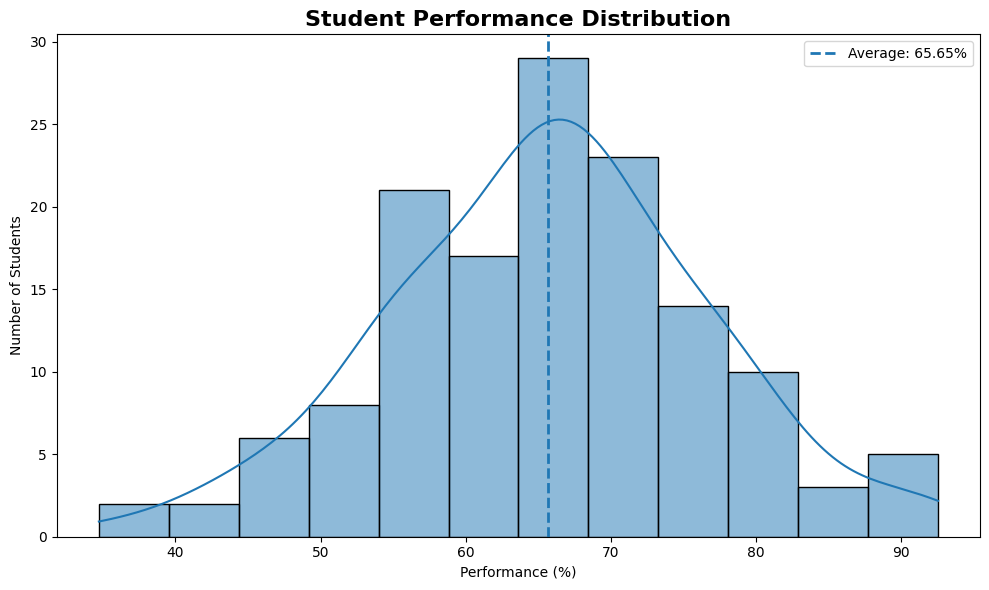

In [24]:

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Performance_Percentage"],
    bins=12,
    kde=True
)

plt.axvline(
    df["Performance_Percentage"].mean(),
    linestyle="--",
    linewidth=2,
    label=f"Average: {df['Performance_Percentage'].mean():.2f}%"
)

plt.title(
    "Student Performance Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Performance (%)")
plt.ylabel("Number of Students")
plt.legend()

plt.tight_layout()
plt.show()

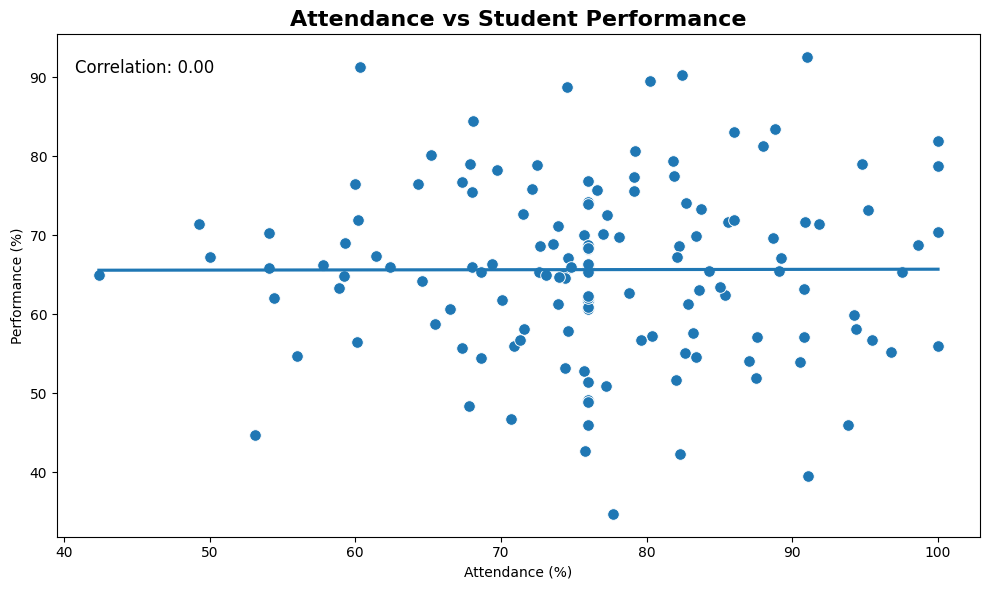

In [25]:
# ============================================
# Cell 25: Attendance vs Performance
# ============================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Attendance_Percentage",
    y="Performance_Percentage",
    s=70
)

# Trend line
sns.regplot(
    data=df,
    x="Attendance_Percentage",
    y="Performance_Percentage",
    scatter=False,
    ci=None
)

correlation = df[
    ["Attendance_Percentage", "Performance_Percentage"]
].corr().iloc[0, 1]

plt.title(
    "Attendance vs Student Performance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Attendance (%)")
plt.ylabel("Performance (%)")

plt.text(
    0.02,
    0.95,
    f"Correlation: {correlation:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top"
)

plt.tight_layout()
plt.show()

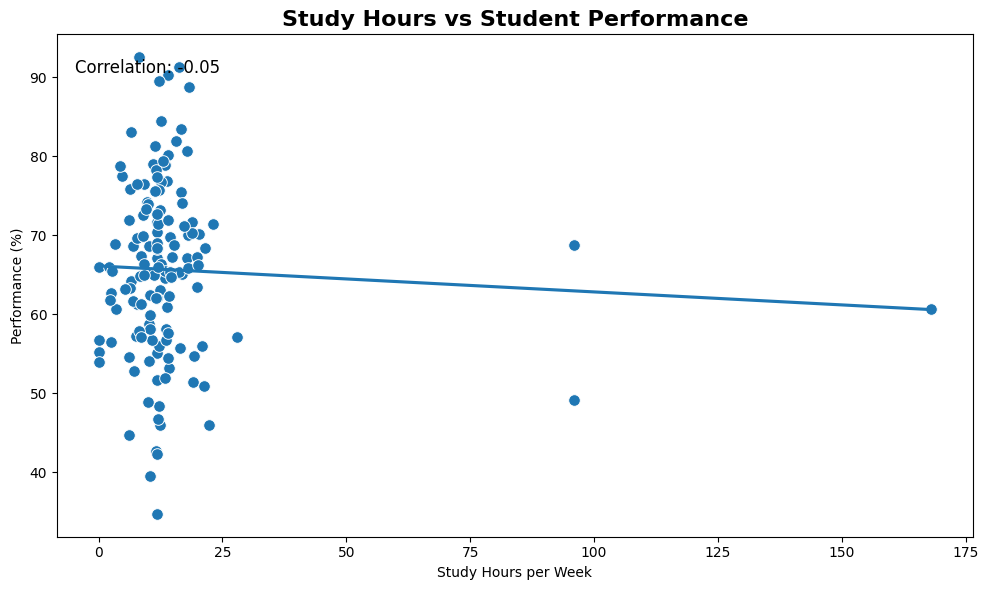

In [26]:
# ============================================
# Cell 26: Study Hours vs Performance
# ============================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Study_Hours_Per_Week",
    y="Performance_Percentage",
    s=70
)

sns.regplot(
    data=df,
    x="Study_Hours_Per_Week",
    y="Performance_Percentage",
    scatter=False,
    ci=None
)

correlation_study = df[
    ["Study_Hours_Per_Week", "Performance_Percentage"]
].corr().iloc[0, 1]

plt.title(
    "Study Hours vs Student Performance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Study Hours per Week")
plt.ylabel("Performance (%)")

plt.text(
    0.02,
    0.95,
    f"Correlation: {correlation_study:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top"
)

plt.tight_layout()
plt.show()

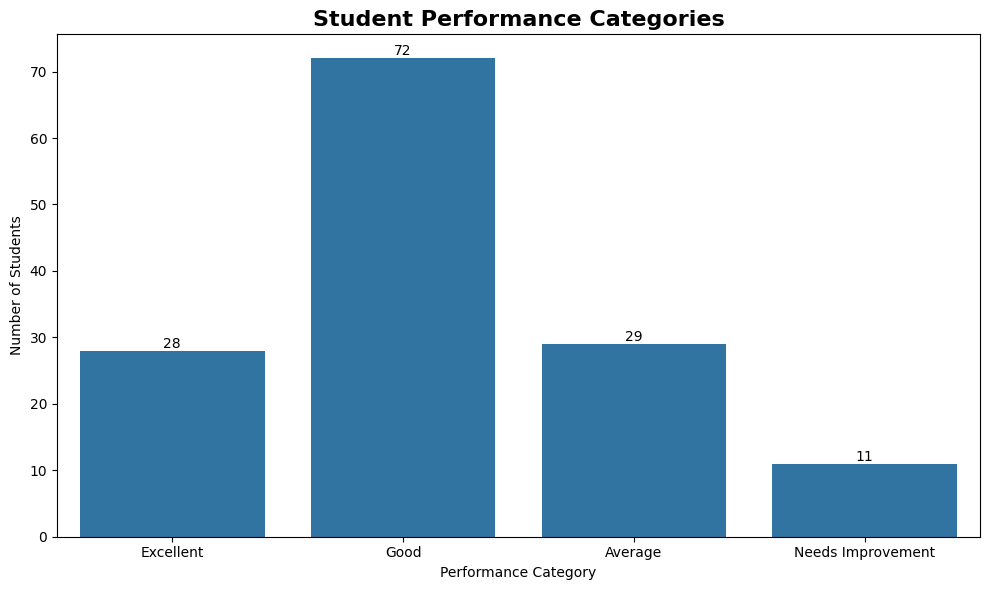

In [27]:
# ============================================
# Cell 27: Performance Category Distribution
# ============================================

category_order = [
    "Excellent",
    "Good",
    "Average",
    "Needs Improvement"
]

category_counts = (
    df["Performance_Category"]
    .value_counts()
    .reindex(category_order)
    .fillna(0)
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=category_counts.index,
    y=category_counts.values
)

plt.title(
    "Student Performance Categories",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Performance Category")
plt.ylabel("Number of Students")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

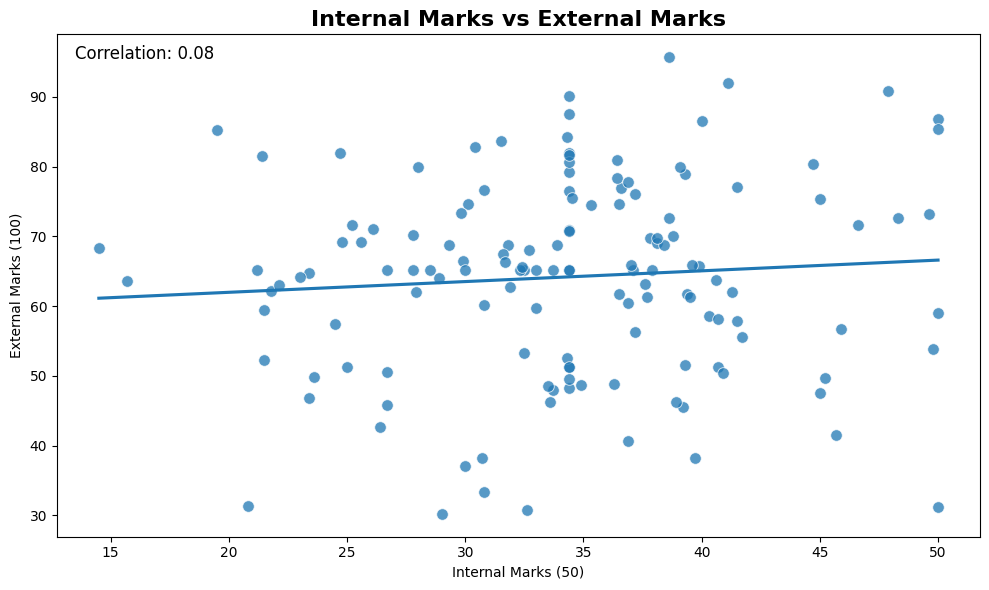

Internal vs External Marks Correlation: 0.08


In [28]:
# ==========================================
# INTERNAL MARKS VS EXTERNAL MARKS
# ==========================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Internal_Marks_50",
    y="External_Marks_100",
    s=70,
    alpha=0.75
)

correlation_marks = df[
    ["Internal_Marks_50", "External_Marks_100"]
].corr().iloc[0, 1]

sns.regplot(
    data=df,
    x="Internal_Marks_50",
    y="External_Marks_100",
    scatter=False,
    ci=None
)

plt.text(
    0.02,
    0.95,
    f"Correlation: {correlation_marks:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12
)

plt.title("Internal Marks vs External Marks", fontsize=16, fontweight="bold")
plt.xlabel("Internal Marks (50)")
plt.ylabel("External Marks (100)")
plt.tight_layout()
plt.show()

print(f"Internal vs External Marks Correlation: {correlation_marks:.2f}")

========== PERFORMANCE BY GENDER ==========
   Gender  Student_Count  Average_Performance
0  Female             61                66.84
1    Male             79                64.73


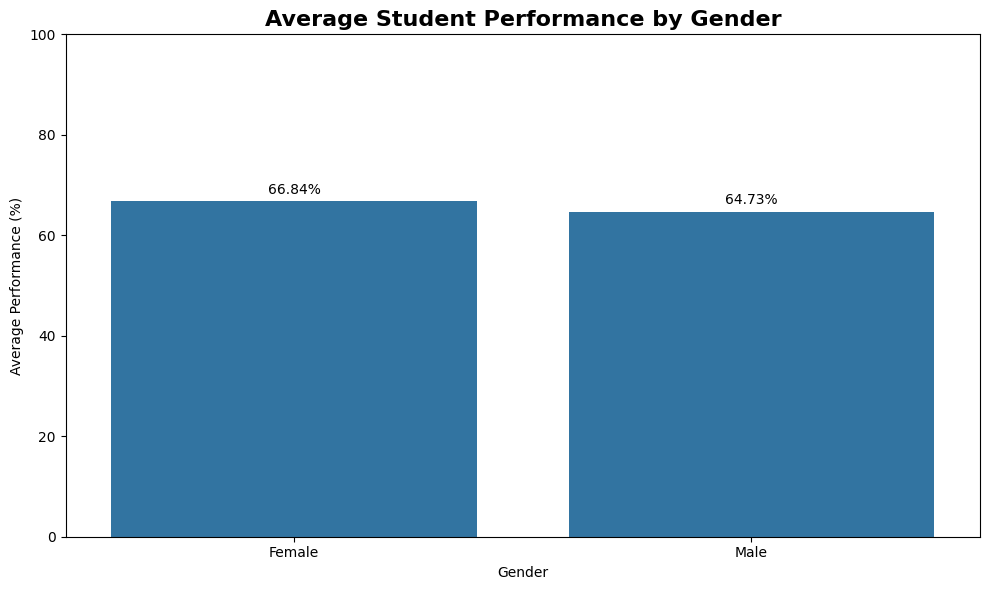

In [29]:
# ==========================================
# PERFORMANCE BY GENDER
# ==========================================

gender_performance = (
    df.groupby("Gender")
      .agg(
          Student_Count=("StudentID", "count"),
          Average_Performance=("Performance_Percentage", "mean")
      )
      .reset_index()
)

gender_performance["Average_Performance"] = (
    gender_performance["Average_Performance"].round(2)
)

print("========== PERFORMANCE BY GENDER ==========")
print(gender_performance)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=gender_performance,
    x="Gender",
    y="Average_Performance"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.title(
    "Average Student Performance by Gender",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Gender")
plt.ylabel("Average Performance (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [30]:
# ==========================================
# AUTOMATED REPORT DATA PREPARATION
# ==========================================

# Performance category summary
category_summary = (
    df["Performance_Category"]
    .value_counts()
    .reindex(
        ["Excellent", "Good", "Average", "Needs Improvement"],
        fill_value=0
    )
    .reset_index()
)

category_summary.columns = ["Performance_Category", "Student_Count"]

category_summary["Percentage"] = (
    category_summary["Student_Count"] / len(df) * 100
).round(2)


# Gender performance summary
gender_summary = (
    df.groupby("Gender")
      .agg(
          Student_Count=("StudentID", "count"),
          Average_Performance=("Performance_Percentage", "mean"),
          Average_Attendance=("Attendance_Percentage", "mean"),
          Average_Study_Hours=("Study_Hours_Per_Week", "mean")
      )
      .reset_index()
)

gender_summary[
    ["Average_Performance", "Average_Attendance", "Average_Study_Hours"]
] = gender_summary[
    ["Average_Performance", "Average_Attendance", "Average_Study_Hours"]
].round(2)


# Executive KPI table
executive_summary = pd.DataFrame({
    "Metric": [
        "Total Students",
        "Average Attendance (%)",
        "Average Study Hours / Week",
        "Average Performance (%)",
        "Highest Performance (%)",
        "Lowest Performance (%)",
        "Average Family Income"
    ],
    "Value": [
        len(df),
        round(df["Attendance_Percentage"].mean(), 2),
        round(df["Study_Hours_Per_Week"].mean(), 2),
        round(df["Performance_Percentage"].mean(), 2),
        round(df["Performance_Percentage"].max(), 2),
        round(df["Performance_Percentage"].min(), 2),
        round(df["Monthly_Family_Income"].mean(), 2)
    ]
})

print("========== REPORT DATA PREPARED ==========")

print("\nExecutive Summary:")
display(executive_summary)

print("\nPerformance Categories:")
display(category_summary)

print("\nGender Summary:")
display(gender_summary)

========== REPORT DATA PREPARED ==========

Executive Summary:


,Metric,Value
0,Total Students,140.00
1,Average Attendance (%),76.74
2,Average Study Hours / Week,14.13
3,Average Performance (%),65.65
4,Highest Performance (%),92.53
5,Lowest Performance (%),34.73
6,Average Family Income,47009.37



Performance Categories:


,Performance_Category,Student_Count,Percentage
0,Excellent,28,20.00
1,Good,72,51.43
2,Average,29,20.71
3,Needs Improvement,11,7.86



Gender Summary:


,Gender,Student_Count,Average_Performance,Average_Attendance,Average_Study_Hours
0,Female,61,66.84,74.90,15.95
1,Male,79,64.73,78.16,12.73


In [32]:
# ==========================================
# FIX DUPLICATE RESOLUTION + SAVE REPORT
# ==========================================

# Create a copy for Excel
duplicate_resolution_excel = duplicate_resolution_df.copy()

# Convert list values into Excel-friendly text
for col in duplicate_resolution_excel.columns:
    duplicate_resolution_excel[col] = duplicate_resolution_excel[col].apply(
        lambda x: ", ".join(map(str, x)) if isinstance(x, list) else x
    )

# ==========================================
# DUPLICATE RESOLUTION SHEET
# ==========================================

ws = wb.create_sheet("Duplicate Resolution")

ws["A1"] = "Duplicate StudentID Resolution Audit"
ws["A1"].font = title_font

# Headers
for col, value in enumerate(duplicate_resolution_excel.columns, 1):
    ws.cell(row=3, column=col, value=value)

# Data
for row_idx, row in enumerate(
    duplicate_resolution_excel.itertuples(index=False),
    start=4
):
    for col_idx, value in enumerate(row, 1):
        ws.cell(row=row_idx, column=col_idx, value=value)

style_header(ws, 3)
format_table(ws)


# ==========================================
# FINAL FORMATTING
# ==========================================

for worksheet in wb.worksheets:
    auto_width(worksheet)

# Freeze important sheets
if "Student Performance" in wb.sheetnames:
    wb["Student Performance"].freeze_panes = "A2"

if "Category Analysis" in wb.sheetnames:
    wb["Category Analysis"].freeze_panes = "A4"

# Save
wb.save(REPORT_PATH)

print("==========================================")
print("AUTOMATED EXCEL REPORT GENERATED")
print("==========================================")
print(f"Saved to: {REPORT_PATH}")
print(f"Sheets created: {len(wb.sheetnames)}")

print("\nSheets:")
for sheet in wb.sheetnames:
    print(f" - {sheet}")

AUTOMATED EXCEL REPORT GENERATED
Saved to: /content/drive/MyDrive/student_dataset/Automated_Student_Performance_Report.xlsx
Sheets created: 8

Sheets:
 - Executive Summary
 - Cleaning Summary
 - Student Performance
 - Category Analysis
 - Gender Analysis
 - Quality Validation
 - Duplicate Resolution
 - Duplicate Resolution1


In [33]:
# ==========================================
# CLEAN DUPLICATE SHEET + FINALIZE REPORT
# ==========================================

# Remove both duplicate-resolution sheets if they exist
for sheet_name in ["Duplicate Resolution", "Duplicate Resolution1"]:
    if sheet_name in wb.sheetnames:
        del wb[sheet_name]

# Create ONE clean Duplicate Resolution sheet
ws = wb.create_sheet("Duplicate Resolution")

ws["A1"] = "Duplicate StudentID Resolution Audit"
ws["A1"].font = title_font

# Convert list values into Excel-friendly text
duplicate_resolution_excel = duplicate_resolution_df.copy()

for col in duplicate_resolution_excel.columns:
    duplicate_resolution_excel[col] = duplicate_resolution_excel[col].apply(
        lambda x: ", ".join(map(str, x)) if isinstance(x, list) else x
    )

# Write headers
for col, value in enumerate(duplicate_resolution_excel.columns, 1):
    ws.cell(row=3, column=col, value=value)

# Write data
for row_idx, row in enumerate(
    duplicate_resolution_excel.itertuples(index=False),
    start=4
):
    for col_idx, value in enumerate(row, 1):
        ws.cell(row=row_idx, column=col_idx, value=value)

style_header(ws, 3)
format_table(ws)

# ==========================================
# FINAL FORMATTING
# ==========================================

for worksheet in wb.worksheets:
    auto_width(worksheet)

# Freeze panes
wb["Student Performance"].freeze_panes = "A2"
wb["Category Analysis"].freeze_panes = "A4"
wb["Duplicate Resolution"].freeze_panes = "A4"

# Save final workbook
wb.save(REPORT_PATH)

# ==========================================
# FINAL CHECK
# ==========================================

print("==========================================")
print("FINAL AUTOMATED REPORT READY")
print("==========================================")
print(f"Saved to: {REPORT_PATH}")
print(f"Total sheets: {len(wb.sheetnames)}")

print("\nFinal Sheets:")
for i, sheet in enumerate(wb.sheetnames, 1):
    print(f"{i}. {sheet}")

FINAL AUTOMATED REPORT READY
Saved to: /content/drive/MyDrive/student_dataset/Automated_Student_Performance_Report.xlsx
Total sheets: 7

Final Sheets:
1. Executive Summary
2. Cleaning Summary
3. Student Performance
4. Category Analysis
5. Gender Analysis
6. Quality Validation
7. Duplicate Resolution
